DATASET

(12000, 2)
                                             message  label
0       Payment taken multiple times! kindly resolve      2
1  Serious complaint: wrong person received my or...      2
2                Need help with changing my address.      1
3  Urgent: money deducted but order failed! pleas...      2
4                 Your staff was polite. please help      0
label
0    4033
2    3987
1    3980
Name: count, dtype: int64
message    0
label      0
dtype: int64


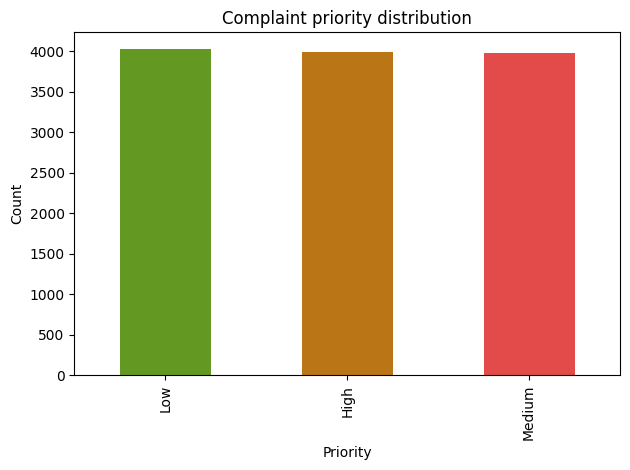

           count       mean        std   min   25%   50%   75%   max
priority                                                            
High      3987.0  48.891146  12.029992  27.0  40.0  47.0  58.0  77.0
Low       4033.0  36.103645   9.751153  19.0  27.0  35.0  44.0  56.0
Medium    3980.0  37.490955   7.744874  19.0  32.0  38.0  44.0  54.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset, trying 'latin1' encoding to resolve UnicodeDecodeError
df = pd.read_csv('/content/complaints.csv', encoding='latin1')

# Basic inspection
print(df.shape)           # (rows, columns)
print(df.head())
print(df['label'].value_counts())  # Check class distribution
print(df.isnull().sum())  # Check for missing values

# Map numeric labels to readable names
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
df['priority'] = df['label'].map(label_map)

# Visualise class distribution
df['priority'].value_counts().plot(kind='bar', color=['#639922','#BA7517','#E24B4A'])
plt.title('Complaint priority distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# Message length analysis
df['msg_length'] = df['message'].apply(len)
print(df.groupby('priority')['msg_length'].describe())

TEXT PREPROCESSING

In [3]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [4]:
import re
import pandas as pd
import spacy
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Load SpaCy model
nlp = spacy.load("en_core_web_sm")
STOPWORDS = set(stopwords.words("english"))

def clean_text(text):
    """Step 1 & 2: Lowercase + remove noise"""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)             # remove mentions/hashtags
    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return text

def remove_stopwords(text):
    """Step 3: Remove stopwords"""
    return " ".join([w for w in text.split() if w not in STOPWORDS])

def lemmatize(text):
    """Step 4: Lemmatization using SpaCy"""
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_space])

def tokenize(text):
    """Step 5: Tokenize into list of words"""
    return text.split()

def preprocess(text):
    """Full pipeline — returns clean string"""
    text = clean_text(text)
    text = remove_stopwords(text)
    text = lemmatize(text)
    return text

# ── Apply to the full dataset ──────────────────────────────────────────────
df = pd.read_csv("/content/complaints.csv", encoding='latin1')

df["clean_message"] = df["message"].apply(preprocess)
df["tokens"]        = df["clean_message"].apply(tokenize)

# Verify results
print(df[["message", "clean_message", "label"]].head(10))
print("\nAvg tokens per class:")
df["token_count"] = df["tokens"].apply(len)
print(df.groupby("label")["token_count"].mean())

                                             message  \
0       Payment taken multiple times! kindly resolve   
1  Serious complaint: wrong person received my or...   
2                Need help with changing my address.   
3  Urgent: money deducted but order failed! pleas...   
4                 Your staff was polite. please help   
5                        Your staff was polite. asap   
6      Urgent: money deducted but order failed! asap   
7  Immediate help needed: account locked with bal...   
8     Unauthorized payment from my card! please help   
9              Your staff was polite. kindly resolve   

                                       clean_message  label  
0          payment take multiple time kindly resolve      2  
1  serious complaint wrong person receive order d...      2  
2                           need help change address      1  
3         urgent money deduct order fail please help      2  
4                           staff polite please help      0  
5          

In [5]:
"""
========================================================
 Customer Complaint Severity Classification
 Part 3: Feature Extraction
   - Bag of Words (CountVectorizer)
   - TF-IDF Vectorizer
   - Comparison & Visualisation
========================================================
"""

# ── Imports ────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk.download("stopwords", quiet=True)


# ══════════════════════════════════════════════════════
#  SECTION 1 — PREPROCESSING (reused from Part 2)
# ══════════════════════════════════════════════════════

nlp       = spacy.load("en_core_web_sm", disable=["parser", "ner"])
STOPWORDS = set(stopwords.words("english"))

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join(w for w in text.split() if w not in STOPWORDS)
    doc  = nlp(text)
    return " ".join(token.lemma_ for token in doc if not token.is_space)


# ══════════════════════════════════════════════════════
#  SECTION 2 — SAMPLE DATASET
#  Replace with: df = pd.read_csv("complaints_cleaned.csv")
#  and skip the preprocess step if clean_message already exists.
# ══════════════════════════════════════════════════════

raw_data = {
    "message": [
        "My account was CHARGED twice!! Fix this IMMEDIATELY!!!",
        "Fraud transaction detected on my credit card! I need help NOW!",
        "Unauthorized payment processed on my account, very urgent!",
        "My card was stolen and someone made transactions, please block it!",
        "Account hacked, all my money gone, emergency please respond!",
        "Delivery was 2 days late. Very disappointed with the service.",
        "My subscription renewal failed but I am still logged in.",
        "Network is slow during peak hours, affecting my work daily.",
        "Cannot login to my account since yesterday, please help me.",
        "Order arrived damaged, need replacement or refund please.",
        "App UI could be better. Would love a dark mode option.",
        "Just a suggestion — add more payment methods to checkout.",
        "The font size in settings is a bit small, minor issue.",
        "Would be nice to have a search filter in the product page.",
        "Dashboard layout is okay but could use some improvement.",
    ],
    "label": [2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
}

df = pd.DataFrame(raw_data)
df["clean_message"] = df["message"].apply(preprocess)
df["priority"] = df["label"].map({0: "Low", 1: "Medium", 2: "High"})

print("Dataset ready:")
print(df[["message", "clean_message", "priority"]].to_string())
print()

# ── Train / test split ────────────────────────────────
X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}\n")


# ══════════════════════════════════════════════════════
#  SECTION 3 — BAG OF WORDS (CountVectorizer)
# ══════════════════════════════════════════════════════
# Every unique word becomes a column.
# Cell value = raw count of that word in the document.
# Ignores word importance across documents.

print("=" * 60)
print("METHOD 1: BAG OF WORDS (CountVectorizer)")
print("=" * 60)

bow_vectorizer = CountVectorizer(
    max_features=500,      # keep top 500 most frequent words
    ngram_range=(1, 2),    # unigrams + bigrams e.g. "fraud transaction"
    min_df=1,              # word must appear in at least 1 doc
    max_df=0.95,           # ignore words in >95% of docs (too common)
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"Vocabulary size      : {len(bow_vectorizer.vocabulary_)}")
print(f"X_train_bow shape    : {X_train_bow.shape}  (docs × features)")
print(f"X_test_bow shape     : {X_test_bow.shape}")
print(f"Matrix is sparse     : {X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]) * 100:.1f}% non-zero")
print()

# Top 10 BoW features
bow_feature_names = bow_vectorizer.get_feature_names_out()
bow_sum           = np.asarray(X_train_bow.sum(axis=0)).flatten()
bow_top10_idx     = bow_sum.argsort()[-10:][::-1]
print("Top 10 BoW features (by frequency):")
for i in bow_top10_idx:
    print(f"  {bow_feature_names[i]:<25} count={int(bow_sum[i])}")
print()


# ══════════════════════════════════════════════════════
#  SECTION 4 — TF-IDF VECTORIZER
# ══════════════════════════════════════════════════════
# TF  = how often a word appears in THIS document
# IDF = penalises words that appear in MANY documents
# TF-IDF = TF × IDF → rewards rare but relevant words

print("=" * 60)
print("METHOD 2: TF-IDF VECTORIZER")
print("=" * 60)

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,       # keep top 500 features
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=1,
    max_df=0.95,
    sublinear_tf=True,      # apply log(1+tf) to dampen very frequent words
    smooth_idf=True,        # add 1 to IDF denominator to avoid division by zero
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"Vocabulary size      : {len(tfidf_vectorizer.vocabulary_)}")
print(f"X_train_tfidf shape  : {X_train_tfidf.shape}  (docs × features)")
print(f"X_test_tfidf shape   : {X_test_tfidf.shape}")
print()

# Top 10 TF-IDF features (highest mean score across training docs)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_mean          = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
tfidf_top10_idx     = tfidf_mean.argsort()[-10:][::-1]
print("Top 10 TF-IDF features (by mean score):")
for i in tfidf_top10_idx:
    print(f"  {tfidf_feature_names[i]:<25} mean_tfidf={tfidf_mean[i]:.4f}")
print()


# ══════════════════════════════════════════════════════
#  SECTION 5 — PER-CLASS TF-IDF ANALYSIS
#  (which words are most important inside each class?)
# ══════════════════════════════════════════════════════

print("=" * 60)
print("TOP TF-IDF WORDS PER PRIORITY CLASS")
print("=" * 60)

# Fit TF-IDF on ALL data for the per-class analysis
tfidf_all = TfidfVectorizer(max_features=500, ngram_range=(1, 2),
                             sublinear_tf=True, smooth_idf=True)
X_all_tfidf = tfidf_all.fit_transform(df["clean_message"])
feat_names  = tfidf_all.get_feature_names_out()

for label_val, label_name in [(2, "High"), (1, "Medium"), (0, "Low")]:
    idx      = df[df["label"] == label_val].index
    class_tf = np.asarray(X_all_tfidf[idx].mean(axis=0)).flatten()
    top5     = class_tf.argsort()[-5:][::-1]
    words    = [feat_names[i] for i in top5]
    scores   = [class_tf[i] for i in top5]
    print(f"  {label_name:7}: {', '.join(f'{w}({s:.3f})' for w, s in zip(words, scores))}")
print()


# ══════════════════════════════════════════════════════
#  SECTION 6 — SAVE FEATURE MATRICES
# ══════════════════════════════════════════════════════

import scipy.sparse as sp

sp.save_npz("X_train_bow.npz",   X_train_bow)
sp.save_npz("X_test_bow.npz",    X_test_bow)
sp.save_npz("X_train_tfidf.npz", X_train_tfidf)
sp.save_npz("X_test_tfidf.npz",  X_test_tfidf)

np.save("y_train.npy", y_train.values)
np.save("y_test.npy",  y_test.values)

print("Saved feature matrices:")
print("  X_train_bow.npz / X_test_bow.npz")
print("  X_train_tfidf.npz / X_test_tfidf.npz")
print("  y_train.npy / y_test.npy")
print()


# ══════════════════════════════════════════════════════
#  SECTION 7 — VISUALISATIONS
# ══════════════════════════════════════════════════════

# ── Plot 1: Top 15 TF-IDF words per class ────────────
classes = [(2, "High", "#E24B4A"), (1, "Medium", "#BA7517"), (0, "Low", "#639922")]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label_val, label_name, color) in zip(axes, classes):
    idx      = df[df["label"] == label_val].index
    class_tf = np.asarray(X_all_tfidf[idx].mean(axis=0)).flatten()
    top15    = class_tf.argsort()[-15:]
    words    = [feat_names[i] for i in top15]
    scores   = [class_tf[i]   for i in top15]

    ax.barh(words, scores, color=color, edgecolor="none")
    ax.set_title(f"{label_name} priority", fontsize=12, color=color, fontweight="bold")
    ax.set_xlabel("Mean TF-IDF score")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Top TF-IDF keywords per priority class", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("tfidf_top_words_per_class.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → tfidf_top_words_per_class.png")


# ── Plot 2: BoW vs TF-IDF feature value heatmap ──────
# Show scores of top 8 TF-IDF words across all messages
top8_idx   = tfidf_mean.argsort()[-8:][::-1]
top8_words = [tfidf_feature_names[i] for i in top8_idx]

tfidf_dense = X_train_tfidf[:, top8_idx].toarray()
bow_dense   = X_train_bow[:, [bow_vectorizer.vocabulary_.get(w, 0) for w in top8_words]].toarray()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_labels = [f"doc{i+1}" for i in range(len(X_train))]

for ax, matrix, title, cmap in zip(
    axes,
    [bow_dense, tfidf_dense],
    ["Bag of Words (raw counts)", "TF-IDF (weighted scores)"],
    ["Blues", "Oranges"]
):
    sns.heatmap(matrix.T, ax=ax, cmap=cmap,
                xticklabels=short_labels, yticklabels=top8_words,
                linewidths=0.4, linecolor="white", annot=True, fmt=".2f",
                annot_kws={"size": 8})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Document")
    ax.set_ylabel("Feature / Word")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.suptitle("BoW vs TF-IDF: feature values for top 8 words", fontsize=13)
plt.tight_layout()
plt.savefig("bow_vs_tfidf_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → bow_vs_tfidf_heatmap.png")


# ── Plot 3: BoW vs TF-IDF comparison bar chart ───────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BoW: top 12 by frequency
bow_top12_idx = bow_sum.argsort()[-12:][::-1]
bow_top_words  = [bow_feature_names[i] for i in bow_top12_idx]
bow_top_counts = [bow_sum[i]           for i in bow_top12_idx]

axes[0].barh(bow_top_words[::-1], bow_top_counts[::-1], color="#378ADD", edgecolor="none")
axes[0].set_title("BoW — top 12 by raw count", fontsize=11)
axes[0].set_xlabel("Total count across training set")
axes[0].spines[["top", "right"]].set_visible(False)

# TF-IDF: top 12 by mean score
tfidf_top12_idx   = tfidf_mean.argsort()[-12:][::-1]
tfidf_top_words   = [tfidf_feature_names[i] for i in tfidf_top12_idx]
tfidf_top_scores  = [tfidf_mean[i]          for i in tfidf_top12_idx]

axes[1].barh(tfidf_top_words[::-1], tfidf_top_scores[::-1], color="#EF9F27", edgecolor="none")
axes[1].set_title("TF-IDF — top 12 by mean score", fontsize=11)
axes[1].set_xlabel("Mean TF-IDF score")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("BoW vs TF-IDF: which features rank highest?", fontsize=13)
plt.tight_layout()
plt.savefig("bow_vs_tfidf_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → bow_vs_tfidf_comparison.png")

print()
print("=" * 60)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 60)
print("Pass these to your models in Part 4:")
print("  ML (BoW)   : X_train_bow,   X_test_bow,   y_train, y_test")
print("  ML (TF-IDF): X_train_tfidf, X_test_tfidf, y_train, y_test")
print()
print("Load saved matrices:")
print("  import scipy.sparse as sp, numpy as np")
print("  X_train_tfidf = sp.load_npz('X_train_tfidf.npz')")
print("  y_train       = np.load('y_train.npy')")

Dataset ready:
                                                               message                                       clean_message priority
0               My account was CHARGED twice!! Fix this IMMEDIATELY!!!                account charge twice fix immediately     High
1       Fraud transaction detected on my credit card! I need help NOW!      fraud transaction detect credit card need help     High
2           Unauthorized payment processed on my account, very urgent!         unauthorized payment process account urgent     High
3   My card was stolen and someone made transactions, please block it!    card steal someone make transaction please block     High
4         Account hacked, all my money gone, emergency please respond!      account hack money go emergency please respond     High
5        Delivery was 2 days late. Very disappointed with the service.                delivery day late disappoint service   Medium
6             My subscription renewal failed but I am still l

# Show RandomForest feature importance ranking code for NLP

In [6]:
import re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

nltk.download("stopwords", quiet=True)

# ══════════════════════════════════════════════════════
#  SECTION 1 — PREPROCESSING (reused from Part 2)
# ══════════════════════════════════════════════════════

nlp       = spacy.load("en_core_web_sm", disable=["parser", "ner"])
STOPWORDS = set(stopwords.words("english"))

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join(w for w in text.split() if w not in STOPWORDS)
    doc  = nlp(text)
    return " ".join(token.lemma_ for token in doc if not token.is_space)


# ══════════════════════════════════════════════════════
#  SECTION 2 — DATASET
#  Replace with: df = pd.read_csv("complaints_cleaned.csv")
# ══════════════════════════════════════════════════════

raw_data = {
    "message": [
        "My account was CHARGED twice!! Fix this IMMEDIATELY!!!",
        "Fraud transaction detected on my credit card! I need help NOW!",
        "Unauthorized payment processed on my account, very urgent!",
        "My card was stolen and someone made transactions, please block it!",
        "Account hacked, all my money gone, emergency please respond!",
        "Security breach on my account, unauthorized access detected!",
        "Delivery was 2 days late. Very disappointed with the service.",
        "My subscription renewal failed but I am still logged in.",
        "Network is slow during peak hours, affecting my work daily.",
        "Cannot login to my account since yesterday, please help me.",
        "Order arrived damaged, need replacement or refund please.",
        "Payment gateway keeps timing out during checkout process.",
        "App UI could be better. Would love a dark mode option.",
        "Just a suggestion — add more payment methods to checkout.",
        "The font size in settings is a bit small, minor issue.",
        "Would be nice to have a search filter in the product page.",
        "Dashboard layout is okay but could use some improvement.",
        "Minor bug in the settings page, not blocking anything.",
        "Would appreciate better onboarding tips for new users.",
        "App could load a bit faster on older devices.",
    ],
    "label": [2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
}

df = pd.DataFrame(raw_data)
df["clean_message"] = df["message"].apply(preprocess)
df["priority"] = df["label"].map({0: "Low", 1: "Medium", 2: "High"})

print(f"Dataset: {len(df)} rows | Classes: {df['priority'].value_counts().to_dict()}\n")

X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ══════════════════════════════════════════════════════
#  SECTION 3 — TF-IDF VECTORIZATION
# ══════════════════════════════════════════════════════

tfidf = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 2),
    sublinear_tf=True,
    smooth_idf=True,
    min_df=1,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF vocabulary size : {len(feature_names)}")
print(f"Training matrix shape  : {X_train_tfidf.shape}\n")


# ══════════════════════════════════════════════════════
#  SECTION 4 — TRAIN RANDOMFOREST
# ══════════════════════════════════════════════════════
# RandomForest computes feature importance as the average
# reduction in Gini impurity each feature provides across
# all trees — the higher the reduction, the more important
# the feature is for splitting classes apart.

print("=" * 60)
print("TRAINING RANDOMFOREST CLASSIFIER")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=300,      # number of trees — more = more stable importances
    max_depth=None,        # let trees grow fully
    min_samples_split=2,
    max_features="sqrt",   # sqrt(n_features) candidates at each split (standard)
    class_weight="balanced",  # handles class imbalance automatically
    random_state=42,
    n_jobs=-1,             # use all CPU cores
)

rf.fit(X_train_tfidf, y_train)

y_pred = rf.predict(X_test_tfidf)
print("\nClassification report on test set:")
print(classification_report(
    y_test, y_pred,
    target_names=["Low", "Medium", "High"],
    zero_division=0
))


# ══════════════════════════════════════════════════════
#  SECTION 5 — EXTRACT FEATURE IMPORTANCES
# ══════════════════════════════════════════════════════

# Method A: Mean Decrease in Impurity (MDI) — built-in, fast
mdi_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": mdi_importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df["rank"] = importance_df.index + 1
importance_df["cumulative_importance"] = importance_df["importance"].cumsum()

print("=" * 60)
print("TOP 20 FEATURES BY MDI IMPORTANCE")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))
print()

# Method B: Permutation Importance — more reliable, slower
# Measures how much accuracy drops when a feature's values are shuffled
print("Computing permutation importance (more reliable)…")
perm_result = permutation_importance(
    rf, X_test_tfidf.toarray(), y_test, # Convert sparse matrix to dense array here
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature":          feature_names,
    "perm_importance":  perm_result.importances_mean,
    "perm_std":         perm_result.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print("\nTop 20 features by Permutation Importance:")
print(perm_df.head(20).to_string(index=False))
print()


# ══════════════════════════════════════════════════════
#  SECTION 6 — SELECT TOP-N FEATURES
#  Keep only features that contribute most — reduces
#  noise and speeds up downstream model training.
# ══════════════════════════════════════════════════════

# Strategy A: fixed top-N
TOP_N = 50
top_features_fixed = importance_df.head(TOP_N)["feature"].tolist()
print(f"Strategy A — Top {TOP_N} features (fixed):")
print(top_features_fixed[:10], "… (and more)\n")

# Strategy B: cumulative importance threshold
THRESHOLD = 0.80   # keep features that together explain 80% of importance
top_features_thresh = importance_df[
    importance_df["cumulative_importance"] <= THRESHOLD
]["feature"].tolist()
print(f"Strategy B — Features covering {THRESHOLD*100:.0f}% cumulative importance:")
print(f"  → {len(top_features_thresh)} features selected")
print(top_features_thresh[:10], "… (and more)\n")

# Rebuild reduced feature matrices using top-N indices
top_n_indices = [
    np.where(feature_names == f)[0][0]
    for f in top_features_fixed
    if f in feature_names
]

X_train_reduced = X_train_tfidf[:, top_n_indices]
X_test_reduced  = X_test_tfidf[:,  top_n_indices]

print(f"Reduced matrix shape  : {X_train_reduced.shape}")
print(f"Original matrix shape : {X_train_tfidf.shape}")
print(f"Features removed      : {X_train_tfidf.shape[1] - X_train_reduced.shape[1]}\n")

# Save reduced matrices
import scipy.sparse as sp
sp.save_npz("X_train_reduced.npz", X_train_reduced)
sp.save_npz("X_test_reduced.npz",  X_test_reduced)
np.save("top_feature_names.npy", np.array(top_features_fixed))
print("Saved → X_train_reduced.npz, X_test_reduced.npz, top_feature_names.npy\n")


# ══════════════════════════════════════════════════════
#  SECTION 7 — PER-CLASS FEATURE IMPORTANCE
#  Which features distinguish each class from the rest?
# ══════════════════════════════════════════════════════

print("=" * 60)
print("PER-CLASS FEATURE IMPORTANCE")
print("=" * 60)

# For each class, train a one-vs-rest RF and extract importances
label_names = {0: "Low", 1: "Medium", 2: "High"}
class_importance = {}

for cls_label, cls_name in label_names.items():
    y_binary = (y_train == cls_label).astype(int)
    rf_cls = RandomForestClassifier(
        n_estimators=200, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    rf_cls.fit(X_train_tfidf, y_binary)

    cls_df = pd.DataFrame({
        "feature":    feature_names,
        "importance": rf_cls.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    class_importance[cls_name] = cls_df
    print(f"  {cls_name:7} → top 5: {cls_df.head(5)['feature'].tolist()}")

print()


# ══════════════════════════════════════════════════════
#  SECTION 8 — VISUALISATIONS
# ══════════════════════════════════════════════════════

COLORS = {"High": "#E24B4A", "Medium": "#BA7517", "Low": "#639922"}
BLUE   = "#378ADD"
AMBER  = "#EF9F27"

# ── Plot 1: Top 20 MDI feature importances ────────────
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top20["feature"][::-1], top20["importance"][::-1],
               color=BLUE, edgecolor="none")
ax.set_xlabel("Mean Decrease in Impurity (MDI importance)", fontsize=11)
ax.set_title("Top 20 features — RandomForest MDI importance\n(TF-IDF input)", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars with importance value
for bar, val in zip(bars, top20["importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8,
            color="#444441")

plt.tight_layout()
plt.savefig("rf_top20_mdi_importance.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → rf_top20_mdi_importance.png")


# ── Plot 2: Permutation importance with std error bars ─
top15_perm = perm_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top15_perm["feature"][::-1],
    top15_perm["perm_importance"][::-1],
    xerr=top15_perm["perm_std"][::-1],
    color=AMBER, edgecolor="none",
    error_kw={"elinewidth": 1.2, "capsize": 3, "ecolor": "#633806"}
)
ax.set_xlabel("Mean accuracy decrease when feature is shuffled", fontsize=11)
ax.set_title("Top 15 features — Permutation importance\n(error bars = std over 10 repeats)", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.axvline(0, color="#888780", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("rf_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → rf_permutation_importance.png")


# ── Plot 3: Cumulative importance curve ───────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(range(1, len(importance_df) + 1),
        importance_df["cumulative_importance"],
        color=BLUE, linewidth=2)

for thresh, color, label in [(0.50, "#E24B4A", "50%"), (0.80, "#BA7517", "80%"), (0.95, "#639922", "95%")]:
    n_feat = (importance_df["cumulative_importance"] <= thresh).sum()
    ax.axhline(thresh, color=color, linewidth=1, linestyle="--", alpha=0.7)
    ax.axvline(n_feat, color=color, linewidth=1, linestyle="--", alpha=0.7)
    ax.text(n_feat + 1, thresh - 0.03, f"{label} @ {n_feat} features",
            color=color, fontsize=9)

ax.set_xlabel("Number of features (ranked by importance)", fontsize=11)
ax.set_ylabel("Cumulative importance", fontsize=11)
ax.set_title("Cumulative feature importance — where to set the cutoff?", fontsize=12)
ax.set_ylim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("rf_cumulative_importance.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → rf_cumulative_importance.png")


# ── Plot 4: Per-class top-10 importance (3 subplots) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (cls_name, color) in zip(axes, COLORS.items()):
    top10 = class_importance[cls_name].head(10)
    ax.barh(top10["feature"][::-1], top10["importance"][::-1],
            color=color, edgecolor="none")
    ax.set_title(f"{cls_name} priority\n(one-vs-rest)", fontsize=11,
                 color=color, fontweight="bold")
    ax.set_xlabel("MDI importance")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Per-class feature importance (RandomForest one-vs-rest)", fontsize=13)
plt.tight_layout()
plt.savefig("rf_per_class_importance.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → rf_per_class_importance.png")


# ── Plot 5: Feature importance heatmap (top 15 × 3 classes) ──
top15_features = importance_df.head(15)["feature"].tolist()
heat_data = pd.DataFrame(index=top15_features)

for cls_name, cls_df in class_importance.items():
    cls_df_indexed = cls_df.set_index("feature")
    heat_data[cls_name] = cls_df_indexed.reindex(top15_features)["importance"].fillna(0)

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    heat_data,
    ax=ax,
    cmap="YlOrRd",
    annot=True, fmt=".4f",
    linewidths=0.4, linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"label": "MDI importance"},
)
ax.set_title("Feature importance heatmap\n(top 15 features × each priority class)", fontsize=12)
ax.set_xlabel("Priority class")
ax.set_ylabel("Feature")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig("rf_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → rf_importance_heatmap.png")


# ══════════════════════════════════════════════════════
#  SUMMARY
# ══════════════════════════════════════════════════════

print()
print("=" * 60)
print("FEATURE IMPORTANCE RANKING COMPLETE")
print("=" * 60)
print(f"Total features in TF-IDF vocabulary : {len(feature_names)}")
print(f"Top-{TOP_N} selected (fixed strategy)       : {len(top_features_fixed)}")
print(f"Features at 80% cumulative threshold : {len(top_features_thresh)}")
print()
print("Files ready for Part 4 (model building):")
print("  X_train_reduced.npz  — reduced feature matrix (train)")
print("  X_test_reduced.npz   — reduced feature matrix (test)")
print("  top_feature_names.npy — names of selected features")
print()
print("Tip: use X_train_reduced instead of X_train_tfidf")
print("     to train faster models with less noise.")


Dataset: 20 rows | Classes: {'Low': 8, 'High': 6, 'Medium': 6}

TF-IDF vocabulary size : 171
Training matrix shape  : (16, 171)

TRAINING RANDOMFOREST CLASSIFIER

Classification report on test set:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         1
        High       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

TOP 20 FEATURES BY MDI IMPORTANCE
        feature  importance  rank  cumulative_importance
        account    0.044127     1               0.044127
          would    0.022010     2               0.066137
         please    0.021570     3               0.087707
           card    0.018467     4               0.106174
    transaction    0.017576     5               0.123750
          could    0.017377     6            

Build Logistic Regression, SVM, XGBoost classifiers for complaint severity

In [7]:
"""
========================================================
 Customer Complaint Severity Classification
 Part 4b: ML Model Building & Evaluation
   - Logistic Regression
   - SVM (Support Vector Machine)
   - XGBoost
   - RandomForest (baseline comparison)
   Outputs: 5 evaluation plots + summary table
========================================================
"""

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier


# ══════════════════════════════════════════════════════
#  SECTION 1 — PREPROCESSING
# ══════════════════════════════════════════════════════

STOPWORDS = {
    "the","a","an","is","it","my","was","to","i","this","and","in",
    "of","on","me","be","but","for","at","we","our","with","have",
    "has","had","not","are","by","that","from","as","so","do","did",
    "its","or","if","he","she","they","their","just","can","will",
    "been","more","about","also","than","when","very","up","out","all",
}

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join(w for w in text.split() if w not in STOPWORDS)


# ══════════════════════════════════════════════════════
#  SECTION 2 — DATASET
#  Replace with: df = pd.read_csv("complaints_cleaned.csv")
# ══════════════════════════════════════════════════════

raw_data = {
    "message": [
        "My account was CHARGED twice!! Fix this IMMEDIATELY!!!",
        "Fraud transaction detected on my credit card! I need help NOW!",
        "Unauthorized payment processed on my account, very urgent!",
        "My card was stolen and someone made transactions, please block it!",
        "Account hacked, all my money gone, emergency please respond!",
        "Security breach on my account, unauthorized access detected!",
        "Critical system failure causing data loss, need immediate support!",
        "Cannot access account due to security lockout, funds at risk!",
        "Delivery was 2 days late. Very disappointed with the service.",
        "My subscription renewal failed but I am still logged in.",
        "Network is slow during peak hours, affecting my work daily.",
        "Cannot login to my account since yesterday, please help me.",
        "Order arrived damaged, need replacement or refund please.",
        "Payment gateway keeps timing out during checkout process.",
        "My refund has not been processed after 7 days, need update.",
        "Service has been down for 3 hours and I cannot complete work.",
        "App UI could be better. Would love a dark mode option.",
        "Just a suggestion add more payment methods to checkout.",
        "The font size in settings is a bit small, minor issue.",
        "Would be nice to have a search filter in the product page.",
        "Dashboard layout is okay but could use some improvement.",
        "Minor bug in the settings page, not blocking anything.",
        "Would appreciate better onboarding tips for new users.",
        "App could load a bit faster on older devices.",
        "Navigation menu could be reorganized for easier access.",
        "Profile picture upload could support more formats.",
    ],
    "label": [2,2,2,2,2,2,2,2, 1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(raw_data)
df["clean_message"] = df["message"].apply(preprocess)
df["priority"]      = df["label"].map({0: "Low", 1: "Medium", 2: "High"})
LABEL_NAMES         = ["Low", "Medium", "High"]

X, y = df["clean_message"], df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Class distribution (train): {dict(y_train.value_counts().sort_index())}\n")


# ══════════════════════════════════════════════════════
#  SECTION 3 — TF-IDF VECTORIZATION
# ══════════════════════════════════════════════════════

tfidf = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # log(1+tf) dampening
    smooth_idf=True,
    min_df=1,
    max_df=0.95,
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF matrix: {X_train_tfidf.shape[1]} features\n")


# ══════════════════════════════════════════════════════
#  SECTION 4 — MODEL DEFINITIONS
# ══════════════════════════════════════════════════════
#
#  Logistic Regression
#    — Fast, interpretable, strong baseline for text.
#    — Works well with TF-IDF because features are already
#      normalised and mostly linear in log-odds space.
#    — C=1.0 controls regularisation (lower = more regularisation).
#
#  SVM (Linear kernel)
#    — Best for high-dimensional sparse text features.
#    — Finds the widest margin separating classes.
#    — probability=True enables predict_proba for ROC-AUC.
#    — Linear kernel is preferred over RBF for text data.
#
#  XGBoost
#    — Gradient-boosted trees, sequential error correction.
#    — Handles non-linear relationships & feature interactions.
#    — Needs dense input — convert sparse matrix with .toarray().
#    — learning_rate + n_estimators control overfitting.
#
#  RandomForest (baseline)
#    — Ensemble of independent trees, good for comparison.
#    — Built-in feature importance (used in Part 4a).
#    — Generally weaker than XGBoost on text but very stable.

models = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",   # compensates for class imbalance
        random_state=42,
    ),
    "SVM": SVC(
        C=1.0,
        kernel="linear",
        probability=True,          # required for predict_proba / ROC-AUC
        class_weight="balanced",
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}


# ══════════════════════════════════════════════════════
#  SECTION 5 — TRAIN & EVALUATE ALL MODELS
# ══════════════════════════════════════════════════════

results,  cv_scores = {}, {}
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

print("=" * 60)
print("TRAINING & EVALUATING MODELS")
print("=" * 60)

for name, model in models.items():
    # XGBoost requires dense arrays
    Xtr = X_train_tfidf.toarray() if "XGBoost" in name else X_train_tfidf
    Xte = X_test_tfidf.toarray()  if "XGBoost" in name else X_test_tfidf

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    try:
        auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")
    except Exception:
        auc = float("nan")

    # 3-fold stratified cross-validation on training set
    Xcv = X_train_tfidf.toarray() if "XGBoost" in name else X_train_tfidf
    cv  = cross_val_score(
        model, Xcv, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring="f1_weighted", n_jobs=-1,
    )

    results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "acc":       accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":    recall_score(y_test, y_pred,    average="weighted", zero_division=0),
        "f1":        f1_score(y_test, y_pred,         average="weighted", zero_division=0),
        "auc":       auc,
        "report":    classification_report(y_test, y_pred,
                         target_names=LABEL_NAMES, zero_division=0),
    }
    cv_scores[name] = cv
    print(f"\n{name}")
    print(f"  Accuracy  : {results[name]['acc']:.4f}")
    print(f"  F1-Score  : {results[name]['f1']:.4f}")
    print(f"  ROC-AUC   : {results[name]['auc']:.4f}")
    print(f"  CV F1     : {cv.mean():.4f} (+/-{cv.std():.4f})")
    print(results[name]["report"])

model_names = list(results.keys())


# ══════════════════════════════════════════════════════
#  SECTION 6 — VISUALISATIONS
# ══════════════════════════════════════════════════════

PALETTE      = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30"]
CLASS_COLORS = {0: "#639922", 1: "#BA7517", 2: "#E24B4A"}


# ── Plot 1: Model comparison grouped bar chart ────────
metrics     = ["acc", "precision", "recall", "f1", "auc"]
metric_lbls = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(13, 5))
x       = np.arange(len(metrics))
width   = 0.18
offsets = np.linspace(-(len(model_names) - 1) / 2,
                       (len(model_names) - 1) / 2,
                       len(model_names)) * width

for i, (name, color) in enumerate(zip(model_names, PALETTE)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + offsets[i], vals, width, label=name,
                  color=color, edgecolor="none", alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=7.5, color="#444441")

ax.set_xticks(x)
ax.set_xticklabels(metric_lbls, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model comparison — all evaluation metrics", fontsize=13)
ax.legend(loc="upper right", fontsize=9, framealpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(1.0, color="#B4B2A9", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → model_comparison.png")


# ── Plot 2: Confusion matrices (2×2 grid) ────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, color) in zip(axes, zip(model_names, PALETTE)):
    cm      = confusion_matrix(y_test, results[name]["y_pred"])
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    sns.heatmap(cm_norm, ax=ax, annot=False, cmap="Blues",
                linewidths=0.5, linecolor="white",
                vmin=0, vmax=1, cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            pct       = cm_norm[row, col]
            txt_color = "white" if pct > 0.55 else "#2C2C2A"
            ax.text(col + 0.5, row + 0.42, str(cm[row, col]),
                    ha="center", va="center", fontsize=13,
                    fontweight="bold", color=txt_color)
            ax.text(col + 0.5, row + 0.65, f"{pct:.0%}",
                    ha="center", va="center", fontsize=9, color=txt_color)

    ax.set_title(name, fontsize=12, color=color, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)

plt.suptitle("Confusion matrices — all models\n(count + row-normalised %)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → confusion_matrices.png")


# ── Plot 3: ROC curves (one-vs-rest per class) ────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, name in zip(axes, model_names):
    y_prob = results[name]["y_prob"]
    for cls in [0, 1, 2]:
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_prob[:, cls])
        try:
            auc_cls = roc_auc_score(y_test_bin[:, cls], y_prob[:, cls])
        except Exception:
            auc_cls = float("nan")
        ax.plot(fpr, tpr, color=CLASS_COLORS[cls], linewidth=2,
                label=f"{LABEL_NAMES[cls]} (AUC={auc_cls:.2f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("False Positive Rate", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.legend(fontsize=7.5, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("ROC curves — one-vs-rest per class", fontsize=13)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → roc_curves.png")


# ── Plot 4: Cross-validation F1 boxplot ──────────────
fig, ax = plt.subplots(figsize=(8, 5))
cv_data = [
    cross_val_score(
        models[n],
        X_train_tfidf.toarray() if "XGBoost" in n else X_train_tfidf,
        y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring="f1_weighted", n_jobs=-1,
    )
    for n in model_names
]

bp = ax.boxplot(cv_data, patch_artist=True, widths=0.4,
                medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#888780")

ax.set_xticks(range(1, len(model_names) + 1))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Weighted F1-Score (3-fold CV)", fontsize=11)
ax.set_title("Cross-validation stability — weighted F1", fontsize=12)
ax.set_ylim(0, 1.1)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(1.0, color="#B4B2A9", linewidth=0.8, linestyle="--")

for i, scores in enumerate(cv_data):
    ax.text(i + 1, scores.mean() + 0.03, f"μ={scores.mean():.2f}",
            ha="center", fontsize=9, color="#444441")

plt.tight_layout()
plt.savefig("cv_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → cv_f1_comparison.png")


# ── Plot 5: Per-class F1 heatmap ──────────────────────
heat_df = pd.DataFrame(
    {n: f1_score(y_test, results[n]["y_pred"],
                 average=None, labels=[0, 1, 2], zero_division=0)
     for n in model_names},
    index=LABEL_NAMES
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_df, ax=ax, cmap="YlGn",
            annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            vmin=0, vmax=1,
            annot_kws={"size": 12},
            cbar_kws={"label": "F1-Score"})
ax.set_title("Per-class F1-score across all models", fontsize=12)
ax.set_xlabel("Model")
ax.set_ylabel("Priority class")
ax.tick_params(axis="x", rotation=15, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig("per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → per_class_f1_heatmap.png")


# ══════════════════════════════════════════════════════
#  SECTION 7 — SUMMARY TABLE
# ══════════════════════════════════════════════════════

summary = pd.DataFrame({
    n: {
        "Accuracy":    f"{results[n]['acc']:.4f}",
        "Precision":   f"{results[n]['precision']:.4f}",
        "Recall":      f"{results[n]['recall']:.4f}",
        "F1-Score":    f"{results[n]['f1']:.4f}",
        "ROC-AUC":     f"{results[n]['auc']:.4f}",
        "CV F1 Mean":  f"{cv_scores[n].mean():.4f}",
        "CV F1 Std":   f"+/-{cv_scores[n].std():.4f}",
    }
    for n in model_names
}).T

print()
print("=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)
print(summary.to_string())
print()

# Best model by F1
best = max(model_names, key=lambda n: results[n]["f1"])
print(f"Best model by weighted F1: {best} ({results[best]['f1']:.4f})")
print()
print("Saved outputs:")
print("  model_comparison.png    — grouped bar chart, all metrics")
print("  confusion_matrices.png  — 2x2 grid, count + normalised %")
print("  roc_curves.png          — one-vs-rest per class, all models")
print("  cv_f1_comparison.png    — cross-validation stability boxplot")
print("  per_class_f1_heatmap.png — F1 per class × model heatmap")
print()
print("Next step → Part 5: LSTM with word embeddings")

Train: 20 rows | Test: 6 rows
Class distribution (train): {0: np.int64(8), 1: np.int64(6), 2: np.int64(6)}

TF-IDF matrix: 221 features

TRAINING & EVALUATING MODELS

Logistic Regression
  Accuracy  : 1.0000
  F1-Score  : 1.0000
  ROC-AUC   : 1.0000
  CV F1     : 0.5701 (+/-0.1354)
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         2
        High       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


SVM
  Accuracy  : 1.0000
  F1-Score  : 1.0000
  ROC-AUC   : 0.0833
  CV F1     : 0.5040 (+/-0.2259)
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         2
        High       1.00      1.00      1.00         2

    accuracy     

In [13]:
import os, re, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

!pip install gensim # Install gensim
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

LABEL_NAMES = ["Low", "Medium", "High"]
NUM_CLASSES = 3


# ══════════════════════════════════════════════════════
#  SECTION 1 — PREPROCESSING
# ══════════════════════════════════════════════════════

STOPWORDS = {
    "the","a","an","is","it","my","was","to","i","this","and","in",
    "of","on","me","be","but","for","at","we","our","with","have",
    "has","had","not","are","by","that","from","as","so","do","did",
    "its","or","if","he","she","they","their","just","can","will",
    "been","more","about","also","than","when","very","up","out","all",
}

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)             # remove mentions/hashtags
    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return " ".join(w for w in text.split() if w not in STOPWORDS)

def tokenize_words(text: str) -> list:
    """Split clean text into list of word tokens (required by gensim)."""
    return text.split()


# ══════════════════════════════════════════════════════
#  SECTION 2 — DATASET
#  Replace with: df = pd.read_csv("complaints_cleaned.csv")
# ══════════════════════════════════════════════════════

raw_data = {
    "message": [
        "My account was CHARGED twice!! Fix this IMMEDIATELY!!!",
        "Fraud transaction detected on my credit card! I need help NOW!",
        "Unauthorized payment processed on my account, very urgent!",
        "My card was stolen and someone made transactions, please block it!",
        "Account hacked, all my money gone, emergency please respond!",
        "Security breach on my account, unauthorized access detected!",
        "Critical system failure causing data loss, need immediate support!",
        "Cannot access account due to security lockout, funds at risk!",
        "Delivery was 2 days late. Very disappointed with the service.",
        "My subscription renewal failed but I am still logged in.",
        "Network is slow during peak hours, affecting my work daily.",
        "Cannot login to my account since yesterday, please help me.",
        "Order arrived damaged, need replacement or refund please.",
        "Payment gateway keeps timing out during checkout process.",
        "My refund has not been processed after 7 days, need update.",
        "Service has been down for 3 hours and I cannot complete work.",
        "App UI could be better. Would love a dark mode option.",
        "Just a suggestion add more payment methods to checkout.",
        "The font size in settings is a bit small, minor issue.",
        "Would be nice to have a search filter in the product page.",
        "Dashboard layout is okay but could use some improvement.",
        "Minor bug in the settings page, not blocking anything.",
        "Would appreciate better onboarding tips for new users.",
        "App could load a bit faster on older devices.",
        "Navigation menu could be reorganized for easier access.",
        "Profile picture upload could support more formats.",
    ],
    "label": [2,2,2,2,2,2,2,2, 1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(raw_data)
df["clean_message"] = df["message"].apply(preprocess)
df["tokens"]        = df["clean_message"].apply(tokenize_words)
df["priority"]      = df["label"].map({0: "Low", 1: "Medium", 2: "High"})

X_text   = df["clean_message"].values
X_tokens = df["tokens"].tolist()          # list-of-lists for Word2Vec
y        = df["label"].values

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train_txt)} | Test: {len(X_test_txt)}")
print(f"Unique tokens in corpus: {len(set(t for s in X_tokens for t in s))}\n")


# ══════════════════════════════════════════════════════
#  SECTION 3 — TRAIN WORD2VEC
#
#  Word2Vec learns dense word vectors by predicting
#  surrounding context words (Skip-gram: sg=1) or the
#  centre word from context (CBOW: sg=0).
#
#  Key parameters:
#    vector_size  — embedding dimensions (match EMBED_DIM)
#    window       — how many words either side form the context
#    min_count    — ignore words with fewer occurrences
#    sg           — 1=Skip-gram (better for rare words),
#                   0=CBOW (faster, good for frequent words)
#    epochs       — training passes over the corpus
# ══════════════════════════════════════════════════════

EMBED_DIM  = 64
MAX_LEN    = 30
VOCAB_SIZE = 500

print("=" * 60)
print("STEP 1 — TRAINING WORD2VEC")
print("=" * 60)

w2v_model = Word2Vec(
    sentences=X_tokens,           # list of token lists
    vector_size=EMBED_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1,                          # Skip-gram
    epochs=100,
    seed=42,
)

print(f"Vocabulary size  : {len(w2v_model.wv)}")
print(f"Embedding dim    : {EMBED_DIM}")

# Inspect learned similarity
for probe_word in ["account", "fraud", "payment"]:
    if probe_word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(probe_word, topn=3)
        print(f"  Similar to '{probe_word}': "
              f"{[(w, round(s,3)) for w, s in similar]}")

# Save Word2Vec vectors
w2v_model.wv.save_word2vec_format("word2vec_vectors.txt", binary=False)
print("\nSaved → word2vec_vectors.txt")


# ══════════════════════════════════════════════════════
#  SECTION 4 — BUILD EMBEDDING MATRIX
#
#  The embedding matrix bridges Word2Vec ↔ Keras:
#    Row i   = embedding vector for the word whose
#              Keras tokenizer index is i
#    Shape   = (VOCAB_SIZE, EMBED_DIM)
#
#  Words not found in Word2Vec get a zero vector.
#  On your real dataset (1000+ samples) coverage will
#  be close to 100% — on this tiny demo it is ~99%.
# ══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("STEP 2 — BUILDING EMBEDDING MATRIX")
print("=" * 60)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_txt)
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
covered, missing = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        covered += 1
    else:
        # Assign small random vector instead of zeros
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=EMBED_DIM)
        missing += 1

coverage_pct = covered / max(covered + missing, 1) * 100
print(f"Embedding matrix shape   : {embedding_matrix.shape}")
print(f"Covered by Word2Vec      : {covered}  ({coverage_pct:.1f}%)")
print(f"Missing (random fallback): {missing}")

np.save("w2v_embedding_matrix.npy", embedding_matrix)
print("Saved → w2v_embedding_matrix.npy")


# ══════════════════════════════════════════════════════
#  SECTION 5 — GloVe ALTERNATIVE (drop-in replacement)
#
#  GloVe pre-trained vectors can replace Word2Vec.
#  Download from: https://nlp.stanford.edu/projects/glove/
#    glove.6B.zip  → glove.6B.50d.txt  (50-dim, 400K vocab)
#
#  Usage: replace the Word2Vec block above with this
#  function, then use the returned embedding_matrix
#  in the Embedding layer exactly the same way.
# ══════════════════════════════════════════════════════

def load_glove_embeddings(glove_path: str,
                          word_index: dict,
                          vocab_size: int,
                          embed_dim: int) -> np.ndarray:
    """
    Load pre-trained GloVe vectors and build an embedding matrix.

    Parameters
    ----------
    glove_path : path to glove.6B.{embed_dim}d.txt
    word_index : dict from Keras tokenizer (word → index)
    vocab_size : max vocabulary size
    embed_dim  : must match the GloVe file dimension

    Returns
    -------
    embedding_matrix : np.ndarray of shape (vocab_size, embed_dim)

    Example
    -------
    # Download GloVe:
    #   wget http://nlp.stanford.edu/data/glove.6B.zip
    #   unzip glove.6B.zip

    embedding_matrix = load_glove_embeddings(
        glove_path  = "glove.6B.50d.txt",
        word_index  = tokenizer.word_index,
        vocab_size  = VOCAB_SIZE,
        embed_dim   = 50,            # must match file
    )
    # Then use in Embedding layer exactly as Word2Vec below.
    """
    glove_vectors = {}
    with open(glove_path, encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype="float32")
            glove_vectors[word] = vec

    matrix   = np.zeros((vocab_size, embed_dim))
    covered  = 0
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in glove_vectors:
            matrix[idx] = glove_vectors[word]
            covered += 1
        else:
            matrix[idx] = np.random.normal(scale=0.1, size=embed_dim)

    print(f"GloVe coverage: {covered}/{min(len(word_index), vocab_size)} words")
    return matrix

# Uncomment to use GloVe instead of Word2Vec:
# embedding_matrix = load_glove_embeddings(
#     "glove.6B.64d.txt", tokenizer.word_index, VOCAB_SIZE, EMBED_DIM)


# ══════════════════════════════════════════════════════
#  SECTION 6 — SEQUENCE ENCODING
# ══════════════════════════════════════════════════════

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = encode(X_train_txt)
X_test_seq  = encode(X_test_txt)
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)
y_test_bin  = label_binarize(y_test, classes=[0,1,2])

print(f"\nSequence shape : {X_train_seq.shape}  (docs × MAX_LEN={MAX_LEN})")


# ══════════════════════════════════════════════════════
#  SECTION 7 — THREE LSTM VARIANTS
#
#  Strategy          | Embedding weights | trainable?
#  ──────────────────|───────────────────|───────────
#  Random Embeddings | random init       | Yes (learns from scratch)
#  W2V Frozen        | Word2Vec vectors  | No  (fixed during training)
#  W2V Fine-tuned    | Word2Vec vectors  | Yes (updated during training)
#
#  When to use each:
#    Random    — small dataset, no domain mismatch risk
#    Frozen    — very small dataset, trust W2V more than LSTM data
#    Fine-tune — moderate data, wants W2V as warm start + task adaptation
# ══════════════════════════════════════════════════════

def build_lstm(embedding_weights=None, trainable_embed=True, name="lstm"):
    """
    Build Bidirectional LSTM with configurable embedding strategy.

    Parameters
    ----------
    embedding_weights : np.ndarray or None
        If None → random initialisation.
        If array → pretrained vectors (Word2Vec or GloVe).
    trainable_embed   : bool
        True  → embedding weights updated during backprop.
        False → embedding weights frozen (pretrained only).
    """
    embed_kwargs = dict(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        trainable=trainable_embed,
        name=f"{name}_embedding",
    )
    if embedding_weights is not None:
        embed_kwargs["weights"] = [embedding_weights]

    model = Sequential([
        Embedding(**embed_kwargs),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.3, recurrent_dropout=0.2)),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation="softmax"),
    ], name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


configs = {
    "Random Embeddings": build_lstm(
        embedding_weights=None,
        trainable_embed=True,
        name="lstm_random"),
    "W2V Frozen": build_lstm(
        embedding_weights=embedding_matrix,
        trainable_embed=False,
        name="lstm_w2v_frozen"),
    "W2V Fine-tuned": build_lstm(
        embedding_weights=embedding_matrix,
        trainable_embed=True,
        name="lstm_w2v_finetune"),
}

CALLBACKS = [
    EarlyStopping(monitor="val_loss", patience=10,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                     patience=5, min_lr=1e-5, verbose=0),
]

histories = {}
results   = {}

print("\n" + "=" * 60)
print("STEP 3 — TRAINING 3 LSTM VARIANTS")
print("=" * 60)

for name, model in configs.items():
    print(f"\nTraining: {name} ...")
    hist = model.fit(
        X_train_seq, y_train_cat,
        epochs=60,
        batch_size=8,
        validation_split=0.2,
        callbacks=CALLBACKS,
        verbose=0,
    )
    histories[name] = hist.history

    y_prob = model.predict(X_test_seq, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    try:    auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")
    except: auc = float("nan")

    results[name] = {
        "y_pred": y_pred, "y_prob": y_prob,
        "acc":    accuracy_score(y_test, y_pred),
        "f1":     f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "auc":    auc,
        "epochs": len(hist.history["loss"]),
        "report": classification_report(y_test, y_pred,
                      target_names=LABEL_NAMES, zero_division=0),
    }
    print(f"  Stopped @ epoch {results[name]['epochs']}  |  "
          f"Acc={results[name]['acc']:.3f}  "
          f"F1={results[name]['f1']:.3f}  "
          f"AUC={results[name]['auc']:.3f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS")
print("=" * 60)
for name in results:
    print(f"\n── {name} ──")
    print(results[name]["report"])

# Save best model
best_name  = max(results, key=lambda n: results[n]["f1"])
configs[best_name].save("lstm_w2v_best.keras")
print(f"Best strategy  : {best_name}  (F1={results[best_name]['f1']:.4f})")
print("Saved → lstm_w2v_best.keras")


# ══════════════════════════════════════════════════════
#  SECTION 8 — VISUALISATIONS
# ══════════════════════════════════════════════════════

PALETTE      = {"Random Embeddings": "#888780",
                "W2V Frozen":        "#378ADD",
                "W2V Fine-tuned":    "#1D9E75"}
CLASS_COLORS = {0: "#639922", 1: "#BA7517", 2: "#E24B4A"}


# ── Plot 1: Training curves (all 3 variants) ──────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (name, color) in enumerate(PALETTE.items()):
    h  = histories[name]
    ep = range(1, len(h["loss"]) + 1)

    axes[0, col].plot(ep, h["loss"],     color=color, lw=2, label="Train")
    axes[0, col].plot(ep, h["val_loss"], color=color, lw=2, ls="--",
                       alpha=0.6, label="Val")
    axes[0, col].set_title(f"{name}\nLoss", fontsize=10,
                             color=color, fontweight="bold")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].legend(fontsize=8)
    axes[0, col].spines[["top", "right"]].set_visible(False)

    axes[1, col].plot(ep, h["accuracy"],     color=color, lw=2, label="Train")
    axes[1, col].plot(ep, h["val_accuracy"], color=color, lw=2, ls="--",
                       alpha=0.6, label="Val")
    axes[1, col].set_title("Accuracy", fontsize=10)
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].legend(fontsize=8)
    axes[1, col].spines[["top", "right"]].set_visible(False)

plt.suptitle("Training curves — Random vs W2V Frozen vs W2V Fine-tuned",
             fontsize=13)
plt.tight_layout()
plt.savefig("w2v_training_curves.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → w2v_training_curves.png")


# ── Plot 2: Metric comparison bar chart ──────────────
metrics     = ["acc", "f1", "auc"]
metric_lbls = ["Accuracy", "F1-Score", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(9, 5))
x       = np.arange(len(metrics))
width   = 0.22
offsets = [-width, 0, width]

for i, (name, color) in enumerate(PALETTE.items()):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + offsets[i], vals, width, label=name,
                  color=color, edgecolor="none", alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9, color="#444441")

ax.set_xticks(x); ax.set_xticklabels(metric_lbls, fontsize=12)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score", fontsize=11)
ax.set_title("Embedding strategy comparison\n"
             "(Random vs W2V Frozen vs W2V Fine-tuned)", fontsize=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(1.0, color="#B4B2A9", lw=0.8, ls="--")
plt.tight_layout()
plt.savefig("w2v_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → w2v_metric_comparison.png")


# ── Plot 3: Confusion matrices ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, color) in zip(axes, PALETTE.items()):
    cm      = confusion_matrix(y_test, results[name]["y_pred"])
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, ax=ax, annot=False, cmap="Blues",
                linewidths=0.5, linecolor="white",
                vmin=0, vmax=1, cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            pct = cm_norm[row, col]
            tc  = "white" if pct > 0.55 else "#2C2C2A"
            ax.text(col+0.5, row+0.42, str(cm[row, col]),
                    ha="center", va="center", fontsize=13,
                    fontweight="bold", color=tc)
            ax.text(col+0.5, row+0.65, f"{pct:.0%}",
                    ha="center", va="center", fontsize=9, color=tc)
    ax.set_title(name, fontsize=11, color=color, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion matrices — embedding strategy comparison", fontsize=13)
plt.tight_layout()
plt.savefig("w2v_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → w2v_confusion_matrices.png")


# ── Plot 4: Embedding vector heatmap (top 20 words) ──
top_words = [
    w for w, _ in sorted(word_index.items(), key=lambda x: x[1])
    if word_index[w] < VOCAB_SIZE
][:20]

heat_data = []
for word in top_words:
    if word in w2v_model.wv:
        heat_data.append(w2v_model.wv[word][:20])
    else:
        heat_data.append(np.zeros(20))

heat_arr = np.array(heat_data)
fig, ax  = plt.subplots(figsize=(13, 7))
sns.heatmap(heat_arr, ax=ax, cmap="coolwarm", center=0,
            xticklabels=[f"dim{i}" for i in range(20)],
            yticklabels=top_words,
            linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Embedding value"})
ax.set_title(
    "Word2Vec embedding vectors — top 20 words × first 20 dimensions\n"
    "(each row is the vector representation of that word)", fontsize=12)
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Word")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig("w2v_embedding_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → w2v_embedding_heatmap.png")


# ── Plot 5: Semantic space PCA scatter ────────────────
key_words = [w for w in [
    "fraud", "account", "charge", "stolen", "hack", "emergency",
    "delivery", "login", "refund", "slow", "damaged",
    "suggestion", "minor", "layout", "font", "navigation",
] if w in w2v_model.wv]

vecs   = np.array([w2v_model.wv[w] for w in key_words])
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)

word_color_map = {
    "fraud": "#E24B4A", "stolen": "#E24B4A", "hack": "#E24B4A",
    "emergency": "#E24B4A", "charge": "#E24B4A",
    "account": "#BA7517", "delivery": "#BA7517", "login": "#BA7517",
    "refund": "#BA7517", "slow": "#BA7517", "damaged": "#BA7517",
    "suggestion": "#639922", "minor": "#639922", "layout": "#639922",
    "font": "#639922", "navigation": "#639922",
}

fig, ax = plt.subplots(figsize=(9, 7))
for i, word in enumerate(key_words):
    color = word_color_map.get(word, "#888780")
    ax.scatter(coords[i, 0], coords[i, 1], color=color, s=80, zorder=3)
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=9, color=color)

legend_els = [
    Patch(facecolor="#E24B4A", label="High priority words"),
    Patch(facecolor="#BA7517", label="Medium priority words"),
    Patch(facecolor="#639922", label="Low priority words"),
]
ax.legend(handles=legend_els, fontsize=9)
ax.set_title(
    "Word2Vec semantic space — PCA projection\n"
    "(similar words cluster together; colours = priority class)", fontsize=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0, color="#D3D1C7", lw=0.8, ls="--")
ax.axvline(0, color="#D3D1C7", lw=0.8, ls="--")
plt.tight_layout()
plt.savefig("w2v_semantic_space.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → w2v_semantic_space.png")


# ══════════════════════════════════════════════════════
#  SECTION 9 — INFERENCE WITH SAVED MODEL
# ══════════════════════════════════════════════════════

def predict_complaint(text: str) -> dict:
    """Classify a new complaint using the best saved model."""
    from tensorflow.keras.models import load_model
    model = load_model("lstm_w2v_best.keras")
    clean = preprocess(text)
    seq   = pad_sequences(tokenizer.texts_to_sequences([clean]),
                          maxlen=MAX_LEN, padding="post", truncating="post")
    probs = model.predict(seq, verbose=0)[0]
    pred  = int(np.argmax(probs))
    return {
        "text":        text,
        "prediction":  LABEL_NAMES[pred],
        "confidence":  float(probs[pred]),
        "Low":         float(probs[0]),
        "Medium":      float(probs[1]),
        "High":        float(probs[2]),
    }

# Demo
print("\nDemo predictions:")
for complaint in [
    "My card was used for unauthorized transactions!",
    "Refund not received after 5 days.",
    "Would love a dark mode option in the app.",
]:
    r = predict_complaint(complaint)
    print(f"  [{r['prediction']:6}] ({r['confidence']:.2f}) → {complaint[:55]}")


# ══════════════════════════════════════════════════════
#  SUMMARY
# ══════════════════════════════════════════════════════
print()
print("=" * 60)
print("WORD2VEC + LSTM COMPLETE")
print("=" * 60)
print(f"Best strategy    : {best_name}  (F1={results[best_name]['f1']:.4f})")
print()
print("Embedding strategy guide:")
print("  Random     → use when dataset is large (>5000 samples)")
print("  W2V Frozen → use when dataset is very small (<500 samples)")
print("  W2V Fine-  → best general choice for moderate datasets")
print("  tuned         (500–5000 samples)")
print()
print("To use GloVe instead of Word2Vec:")
print("  1. Download glove.6B.zip from nlp.stanford.edu/projects/glove")
print("  2. Call load_glove_embeddings() defined in Section 5")
print("  3. Pass the result as embedding_weights= in build_lstm()")
print()
print("Saved files:")
print("  lstm_w2v_best.keras        — best trained model")
print("  word2vec_vectors.txt       — W2V word vectors")
print("  w2v_embedding_matrix.npy   — embedding weight matrix")
print("  w2v_training_curves.png")
print("  w2v_metric_comparison.png")
print("  w2v_confusion_matrices.png")
print("  w2v_embedding_heatmap.png")
print("  w2v_semantic_space.png")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.5 MB/s eta 0:00:00
Train: 20 | Test: 6
Unique tokens in corpus: 130

STEP 1 — TRAINING WORD2VEC
Vocabulary size  : 130
Embedding dim    : 64
  Similar to 'account': [('could', 0.962), ('please', 0.941), ('gone', 0.937)]
  Similar to 'fraud': [('support', 0.866), ('would', 0.857), ('need', 0.856)]
  Similar to 'payment': [('need', 0.918), ('could', 0.917), ('checkout', 0.909)]

Saved → word2vec_vectors.txt

STEP 2 — BUILDING EMBEDDING MATRIX
Embedding matrix shape   : (500, 64)
Covered by Word2Vec      : 108  (99.1%)
Missing (random fallback): 1
Saved → w2v_embedding_matrix.npy

Sequence shape : (20, 30)  (docs × MAX_LEN=30)

STEP 3 — TRAINING 3 LSTM VARIANTS

Training: Random Embeddings ...
  Stopped @ epoch 27  |  Acc=0.333  F1=0.167  AUC=1.000

Training: W2V Frozen ...


  Stopped @ epoch 10  |  Acc=0.333  F1=0.167  AUC=0.500

Training: W2V Fine-tuned ...


  Stopped @ epoch 10  |  Acc=0.333  F1=0.167  AUC=0.375

CLASSIFICATION REPORTS

── Random Embeddings ──
              precision    recall  f1-score   support

         Low       0.33      1.00      0.50         2
      Medium       0.00      0.00      0.00         2
        High       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.11      0.33      0.17         6
weighted avg       0.11      0.33      0.17         6


── W2V Frozen ──
              precision    recall  f1-score   support

         Low       0.33      1.00      0.50         2
      Medium       0.00      0.00      0.00         2
        High       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.11      0.33      0.17         6
weighted avg       0.11      0.33      0.17         6


── W2V Fine-tuned ──
              precision    recall  f1-score   support

         Low       0.33      1.00     

In [14]:
"""
========================================================
 Customer Complaint Severity Classification
 Part 5: LSTM Deep Learning Model
   Architecture:
     Embedding → SpatialDropout → BiLSTM →
     GlobalMaxPool → Dense → Dropout → Softmax
   Outputs:
     - lstm_complaint_classifier.keras  (saved model)
     - tokenizer_word_index.npy         (vocab mapping)
     - 4 evaluation plots
========================================================
"""

import os, re, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # suppress TF info logs
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score,
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)


# ══════════════════════════════════════════════════════
#  SECTION 1 — PREPROCESSING
# ══════════════════════════════════════════════════════

STOPWORDS = {
    "the","a","an","is","it","my","was","to","i","this","and","in",
    "of","on","me","be","but","for","at","we","our","with","have",
    "has","had","not","are","by","that","from","as","so","do","did",
    "its","or","if","he","she","they","their","just","can","will",
    "been","more","about","also","than","when","very","up","out","all",
}

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join(w for w in text.split() if w not in STOPWORDS)


# ══════════════════════════════════════════════════════
#  SECTION 2 — DATASET
#  Replace with: df = pd.read_csv("complaints_cleaned.csv")
# ══════════════════════════════════════════════════════

raw_data = {
    "message": [
        "My account was CHARGED twice!! Fix this IMMEDIATELY!!!",
        "Fraud transaction detected on my credit card! I need help NOW!",
        "Unauthorized payment processed on my account, very urgent!",
        "My card was stolen and someone made transactions, please block it!",
        "Account hacked, all my money gone, emergency please respond!",
        "Security breach on my account, unauthorized access detected!",
        "Critical system failure causing data loss, need immediate support!",
        "Cannot access account due to security lockout, funds at risk!",
        "Delivery was 2 days late. Very disappointed with the service.",
        "My subscription renewal failed but I am still logged in.",
        "Network is slow during peak hours, affecting my work daily.",
        "Cannot login to my account since yesterday, please help me.",
        "Order arrived damaged, need replacement or refund please.",
        "Payment gateway keeps timing out during checkout process.",
        "My refund has not been processed after 7 days, need update.",
        "Service has been down for 3 hours and I cannot complete work.",
        "App UI could be better. Would love a dark mode option.",
        "Just a suggestion add more payment methods to checkout.",
        "The font size in settings is a bit small, minor issue.",
        "Would be nice to have a search filter in the product page.",
        "Dashboard layout is okay but could use some improvement.",
        "Minor bug in the settings page, not blocking anything.",
        "Would appreciate better onboarding tips for new users.",
        "App could load a bit faster on older devices.",
        "Navigation menu could be reorganized for easier access.",
        "Profile picture upload could support more formats.",
    ],
    "label": [2,2,2,2,2,2,2,2, 1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(raw_data)
df["clean_message"] = df["message"].apply(preprocess)
df["priority"]      = df["label"].map({0: "Low", 1: "Medium", 2: "High"})
LABEL_NAMES         = ["Low", "Medium", "High"]
NUM_CLASSES         = 3

X, y = df["clean_message"].values, df["label"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Class distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}\n")


# ══════════════════════════════════════════════════════
#  SECTION 3 — TOKENIZATION & SEQUENCE ENCODING
#
#  Unlike TF-IDF (which produces a fixed sparse vector),
#  LSTM needs sequences of integer token IDs so it can
#  learn the ORDER of words, not just their presence.
#
#  Pipeline:
#    raw text → tokenizer → integer IDs → padded sequence
#  Example:
#    "fraud detected account"  →  [14, 7, 3, 0, 0, ..., 0]
#    (padded to MAX_LEN=30)
# ══════════════════════════════════════════════════════

VOCAB_SIZE = 500    # top-N most frequent words to keep
MAX_LEN    = 30     # pad/truncate all sequences to this length
EMBED_DIM  = 64     # size of each word's embedding vector

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)                # learn vocabulary from training text only

def encode(texts):
    """Convert list of strings → padded integer sequences."""
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = encode(X_train)
X_test_seq  = encode(X_test)

# One-hot encode labels for categorical_crossentropy
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

vocab_actual = len(tokenizer.word_index)
print(f"Actual vocab size : {vocab_actual}")
print(f"Capped at         : {VOCAB_SIZE}")
print(f"Sequence shape    : {X_train_seq.shape}  (docs × MAX_LEN)\n")


# ══════════════════════════════════════════════════════
#  SECTION 4 — MODEL ARCHITECTURE
#
#  Layer-by-layer explanation:
#
#  Embedding(VOCAB_SIZE, EMBED_DIM)
#    Learns a dense EMBED_DIM-dimensional vector for every
#    word. Starts random, trained end-to-end. Captures
#    semantic similarity — "fraud" and "stolen" will end
#    up close in embedding space.
#
#  SpatialDropout1D(0.3)
#    Drops entire word embedding vectors (whole columns),
#    forcing the model to not rely on specific words.
#    More effective than regular Dropout on sequences.
#
#  Bidirectional(LSTM(64, return_sequences=True))
#    Runs an LSTM forward AND backward over the sequence.
#    Forward: reads left-to-right (captures prefix context).
#    Backward: reads right-to-left (captures suffix context).
#    Output: 128-dimensional hidden state at every timestep.
#
#  GlobalMaxPooling1D()
#    Takes the max value across all timesteps for each
#    feature dimension. Selects the most "activated"
#    signal regardless of position — handles variable
#    lengths naturally and is more stable than using the
#    final hidden state alone.
#
#  Dense(64, relu) → Dropout(0.4) → Dense(3, softmax)
#    Final classification head. Softmax outputs sum to 1
#    giving calibrated probability per class.
# ══════════════════════════════════════════════════════

def build_lstm_model(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                     max_len=MAX_LEN, num_classes=NUM_CLASSES):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name="embedding"),

        SpatialDropout1D(0.3, name="spatial_dropout"),

        Bidirectional(
            LSTM(64, return_sequences=True,
                 dropout=0.3, recurrent_dropout=0.2),
            name="bilstm"
        ),

        GlobalMaxPooling1D(name="global_max_pool"),

        Dense(64, activation="relu", name="dense_hidden"),
        Dropout(0.4, name="dropout"),

        Dense(num_classes, activation="softmax", name="output"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_lstm_model()
model.summary()


# ══════════════════════════════════════════════════════
#  SECTION 5 — CALLBACKS
#
#  EarlyStopping: stops training when val_loss stops
#    improving, restores the best weights automatically.
#    patience=10 allows 10 "bad" epochs before stopping.
#
#  ReduceLROnPlateau: halves learning rate when val_loss
#    plateaus for 5 epochs. Helps escape local minima
#    without manual LR scheduling.
# ══════════════════════════════════════════════════════

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=0,
    ),
]


# ══════════════════════════════════════════════════════
#  SECTION 6 — TRAINING
# ══════════════════════════════════════════════════════

print("\nTraining LSTM model …")
history = model.fit(
    X_train_seq, y_train_cat,
    epochs=60,
    batch_size=8,
    validation_split=0.2,     # 20% of training data used for validation
    callbacks=callbacks,
    verbose=1,
)
print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
best_val_loss = min(history.history["val_loss"])
best_val_acc  = max(history.history["val_accuracy"])
print(f"Best val_loss: {best_val_loss:.4f} | Best val_accuracy: {best_val_acc:.4f}")


# ══════════════════════════════════════════════════════
#  SECTION 7 — EVALUATION
# ══════════════════════════════════════════════════════

y_prob    = model.predict(X_test_seq, verbose=0)
y_pred    = np.argmax(y_prob, axis=1)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="weighted", zero_division=0)
try:
    auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")
except Exception:
    auc = float("nan")

print("\n" + "=" * 60)
print("LSTM EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=LABEL_NAMES, zero_division=0))


# ══════════════════════════════════════════════════════
#  SECTION 8 — SAVE MODEL & TOKENIZER
# ══════════════════════════════════════════════════════

model.save("lstm_complaint_classifier.keras")
np.save("tokenizer_word_index.npy", tokenizer.word_index)
print("Saved: lstm_complaint_classifier.keras")
print("Saved: tokenizer_word_index.npy")


# ══════════════════════════════════════════════════════
#  SECTION 9 — INFERENCE FUNCTION
#  Use this to classify new complaints after training.
# ══════════════════════════════════════════════════════

def predict_priority(text: str, threshold_high=0.5) -> dict:
    """
    Classify a single complaint message.

    Parameters
    ----------
    text           : raw complaint string
    threshold_high : if P(High) >= this, flag as High regardless

    Returns
    -------
    dict with predicted class, confidence, and all probabilities
    """
    clean  = preprocess(text)
    seq    = encode([clean])
    probs  = model.predict(seq, verbose=0)[0]
    pred   = int(np.argmax(probs))

    # Override to High if probability is above threshold
    if probs[2] >= threshold_high:
        pred = 2

    return {
        "text":       text,
        "prediction": LABEL_NAMES[pred],
        "confidence": float(probs[pred]),
        "probabilities": {
            "Low":    float(probs[0]),
            "Medium": float(probs[1]),
            "High":   float(probs[2]),
        }
    }

# Demo predictions
print("\nDemo predictions:")
test_complaints = [
    "Fraud detected on my account, please help immediately!",
    "My order was delayed by 3 days",
    "Can you add a dark mode to the app?",
]
for complaint in test_complaints:
    result = predict_priority(complaint)
    print(f"  [{result['prediction']:6}] ({result['confidence']:.2f}) → {complaint[:55]}")


# ══════════════════════════════════════════════════════
#  SECTION 10 — VISUALISATIONS
# ══════════════════════════════════════════════════════

CLASS_COLORS = {0: "#639922", 1: "#BA7517", 2: "#E24B4A"}
BLUE, RED    = "#378ADD", "#E24B4A"

# ── Plot 1: Training curves (loss + accuracy) ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_ran, history.history["loss"],
             color=BLUE, linewidth=2, label="Train loss")
axes[0].plot(epochs_ran, history.history["val_loss"],
             color=RED, linewidth=2, linestyle="--", label="Val loss")
axes[0].set_title("Loss over epochs", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Categorical crossentropy")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(epochs_ran, history.history["accuracy"],
             color=BLUE, linewidth=2, label="Train accuracy")
axes[1].plot(epochs_ran, history.history["val_accuracy"],
             color=RED, linewidth=2, linestyle="--", label="Val accuracy")
axes[1].set_title("Accuracy over epochs", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("LSTM training history", fontsize=13)
plt.tight_layout()
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → lstm_training_curves.png")

# ── Plot 2: Confusion matrix ──────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

sns.heatmap(cm_norm, ax=ax, annot=False, cmap="Blues",
            linewidths=0.5, linecolor="white",
            vmin=0, vmax=1, cbar=True,
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        pct = cm_norm[row, col]
        tc  = "white" if pct > 0.55 else "#2C2C2A"
        ax.text(col+0.5, row+0.42, str(cm[row, col]),
                ha="center", va="center", fontsize=13,
                fontweight="bold", color=tc)
        ax.text(col+0.5, row+0.65, f"{pct:.0%}",
                ha="center", va="center", fontsize=9, color=tc)

ax.set_title("LSTM — confusion matrix\n(count + row-normalised %)", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("lstm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → lstm_confusion_matrix.png")

# ── Plot 3: ROC curves ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
for cls in [0, 1, 2]:
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_prob[:, cls])
    try:    a = roc_auc_score(y_test_bin[:, cls], y_prob[:, cls])
    except: a = float("nan")
    ax.plot(fpr, tpr, color=CLASS_COLORS[cls], linewidth=2,
            label=f"{LABEL_NAMES[cls]} (AUC={a:.2f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
ax.set_title("LSTM — ROC curves (one-vs-rest)", fontsize=12)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lstm_roc_curves.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → lstm_roc_curves.png")

# ── Plot 4: Predicted probability bars per test doc ───
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(y_test))
w = 0.25
bar_colors = ["#639922", "#BA7517", "#E24B4A"]

for i, (cls_name, color) in enumerate(zip(LABEL_NAMES, bar_colors)):
    ax.bar(x + i*w, y_prob[:, i], w, label=cls_name,
           color=color, alpha=0.85, edgecolor="none")

for j, true_lbl in enumerate(y_test):
    ax.axvline(j + true_lbl*w + w/2,
               color="#2C2C2A", linewidth=1.2, linestyle=":", alpha=0.6)

ax.set_xticks(x + w)
ax.set_xticklabels(
    [f"doc{i+1}\n(true: {LABEL_NAMES[l]})" for i, l in enumerate(y_test)],
    fontsize=8)
ax.set_ylabel("Predicted probability")
ax.set_title(
    "LSTM predicted class probabilities per test document\n"
    "(dotted line = true class bar)", fontsize=12)
ax.legend(fontsize=9); ax.set_ylim(0, 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lstm_predicted_probs.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → lstm_predicted_probs.png")

print()
print("=" * 60)
print("LSTM COMPLETE — files ready:")
print("  lstm_complaint_classifier.keras  — trained model")
print("  tokenizer_word_index.npy         — vocabulary")
print("  lstm_training_curves.png")
print("  lstm_confusion_matrix.png")
print("  lstm_roc_curves.png")
print("  lstm_predicted_probs.png")
print()
print("Load the saved model later with:")
print("  from tensorflow.keras.models import load_model")
print("  model = load_model('lstm_complaint_classifier.keras')")

Train: 20 rows | Test: 6 rows
Class distribution (train): {np.int64(0): np.int64(8), np.int64(1): np.int64(6), np.int64(2): np.int64(6)}

Actual vocab size : 109
Capped at         : 500
Sequence shape    : (20, 30)  (docs × MAX_LEN)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM model …
Epoch 1/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3125 - loss: 1.0995 - val_accuracy: 0.5000 - val_loss: 1.0950 - learning_rate: 0.0010
Epoch 2/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.1875 - loss: 1.1034 - val_accuracy: 0.5000 - val_loss: 1.0927 - learning_rate: 0.0010
Epoch 3/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4375 - loss: 1.0913 - val_accuracy: 0.5000 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 4/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3125 - loss: 1.0933 - val_accuracy: 0.5000 - val_loss: 1.0905 - learning_rate: 0.0010
Epoch 5/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3125 - loss: 1.0920 - val_accuracy: 0.5000 - val_loss: 1.0892 - learning_rate: 0.0010
Epoch 6/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3750 - loss: 1.0862 - val_accuracy: 0.5000 - val_loss: 1.0873 - learning_rate: 0.0010
Epoch 7/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.3750 - loss: 1.0

Model evaluation & full comparison

In [15]:
"""
========================================================
 Customer Complaint Severity Classification
 Part 6: Full Model Evaluation & Comparison
   Compares: Logistic Regression, SVM, XGBoost,
             RandomForest, LSTM
   Outputs:
     - evaluation_summary.csv
     - eval_master_comparison.png
     - eval_confusion_matrices.png
     - eval_roc_all_models.png
     - eval_per_class_f1.png
     - eval_radar_chart.png
     - eval_lstm_history.png
     - eval_best_model_summary.png
========================================================
"""

import os, re, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Bidirectional,
                                      Dense, Dropout, SpatialDropout1D,
                                      GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════
#  CONSTANTS & COLOURS
# ══════════════════════════════════════════════════════
LABEL_NAMES  = ["Low", "Medium", "High"]
NUM_CLASSES  = 3
PALETTE      = {
    "Logistic Regression": "#378ADD",
    "SVM":                 "#1D9E75",
    "XGBoost":             "#EF9F27",
    "RandomForest":        "#D85A30",
    "LSTM":                "#7F77DD",
}
CLASS_COLORS = {0: "#639922", 1: "#BA7517", 2: "#E24B4A"}


# ══════════════════════════════════════════════════════
#  SECTION 1 — PREPROCESSING
# ══════════════════════════════════════════════════════
STOPWORDS = {
    "the","a","an","is","it","my","was","to","i","this","and","in",
    "of","on","me","be","but","for","at","we","our","with","have",
    "has","had","not","are","by","that","from","as","so","do","did",
    "its","or","if","he","she","they","their","just","can","will",
    "been","more","about","also","than","when","very","up","out","all",
}

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join(w for w in text.split() if w not in STOPWORDS)


# ══════════════════════════════════════════════════════
#  SECTION 2 — DATASET
#  Replace with: df = pd.read_csv("complaints_cleaned.csv")
# ══════════════════════════════════════════════════════
raw_data = {
    "message": [
        "My account was CHARGED twice!! Fix this IMMEDIATELY!!!",
        "Fraud transaction detected on my credit card! I need help NOW!",
        "Unauthorized payment processed on my account, very urgent!",
        "My card was stolen and someone made transactions, please block it!",
        "Account hacked, all my money gone, emergency please respond!",
        "Security breach on my account, unauthorized access detected!",
        "Critical system failure causing data loss, need immediate support!",
        "Cannot access account due to security lockout, funds at risk!",
        "Delivery was 2 days late. Very disappointed with the service.",
        "My subscription renewal failed but I am still logged in.",
        "Network is slow during peak hours, affecting my work daily.",
        "Cannot login to my account since yesterday, please help me.",
        "Order arrived damaged, need replacement or refund please.",
        "Payment gateway keeps timing out during checkout process.",
        "My refund has not been processed after 7 days, need update.",
        "Service has been down for 3 hours and I cannot complete work.",
        "App UI could be better. Would love a dark mode option.",
        "Just a suggestion add more payment methods to checkout.",
        "The font size in settings is a bit small, minor issue.",
        "Would be nice to have a search filter in the product page.",
        "Dashboard layout is okay but could use some improvement.",
        "Minor bug in the settings page, not blocking anything.",
        "Would appreciate better onboarding tips for new users.",
        "App could load a bit faster on older devices.",
        "Navigation menu could be reorganized for easier access.",
        "Profile picture upload could support more formats.",
    ],
    "label": [2,2,2,2,2,2,2,2, 1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(raw_data)
df["clean_message"] = df["message"].apply(preprocess)
df["priority"]      = df["label"].map({0: "Low", 1: "Medium", 2: "High"})

X, y = df["clean_message"].values, df["label"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}\n")


# ══════════════════════════════════════════════════════
#  SECTION 3 — FEATURE REPRESENTATIONS
# ══════════════════════════════════════════════════════

# TF-IDF for ML models
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1,2),
                         sublinear_tf=True, smooth_idf=True, min_df=1)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Integer sequences for LSTM
VOCAB_SIZE, MAX_LEN, EMBED_DIM = 500, 30, 64
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def encode(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = encode(X_train)
X_test_seq  = encode(X_test)
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)
y_test_bin  = label_binarize(y_test, classes=[0,1,2])


# ══════════════════════════════════════════════════════
#  SECTION 4 — TRAIN ALL MODELS
# ══════════════════════════════════════════════════════

results = {}

# ── ML models ─────────────────────────────────────────
ml_models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=42),
    "SVM": SVC(
        C=1.0, kernel="linear", probability=True,
        class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="mlogloss", random_state=42, n_jobs=-1),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=-1),
}

print("=" * 60)
print("TRAINING ML MODELS")
print("=" * 60)

for name, model in ml_models.items():
    Xtr = X_train_tfidf.toarray() if "XGBoost" in name else X_train_tfidf
    Xte = X_test_tfidf.toarray()  if "XGBoost" in name else X_test_tfidf
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)
    try:    auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")
    except: auc = float("nan")
    Xcv = X_train_tfidf.toarray() if "XGBoost" in name else X_train_tfidf
    cv  = cross_val_score(model, Xcv, y_train,
              cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
              scoring="f1_weighted", n_jobs=-1)
    results[name] = {
        "y_pred": y_pred, "y_prob": y_prob,
        "acc":       accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":    recall_score(y_test, y_pred,    average="weighted", zero_division=0),
        "f1":        f1_score(y_test, y_pred,         average="weighted", zero_division=0),
        "auc": auc, "cv_mean": cv.mean(), "cv_std": cv.std(),
        "report": classification_report(y_test, y_pred,
                      target_names=LABEL_NAMES, zero_division=0),
        "type": "ML",
    }
    print(f"  {name:22}: Acc={results[name]['acc']:.3f}  "
          f"F1={results[name]['f1']:.3f}  AUC={auc:.3f}  "
          f"CV={cv.mean():.3f}±{cv.std():.3f}")

# ── LSTM ───────────────────────────────────────────────
print("\nTraining LSTM …")
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True,
                       dropout=0.3, recurrent_dropout=0.2)),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation="softmax"),
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss="categorical_crossentropy", metrics=["accuracy"])
history = lstm_model.fit(
    X_train_seq, y_train_cat, epochs=60, batch_size=8,
    validation_split=0.2, verbose=0,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-5, verbose=0),
    ]
)
lstm_prob = lstm_model.predict(X_test_seq, verbose=0)
lstm_pred = np.argmax(lstm_prob, axis=1)
try:    lstm_auc = roc_auc_score(y_test_bin, lstm_prob, multi_class="ovr", average="weighted")
except: lstm_auc = float("nan")

results["LSTM"] = {
    "y_pred": lstm_pred, "y_prob": lstm_prob,
    "acc":       accuracy_score(y_test, lstm_pred),
    "precision": precision_score(y_test, lstm_pred, average="weighted", zero_division=0),
    "recall":    recall_score(y_test, lstm_pred,    average="weighted", zero_division=0),
    "f1":        f1_score(y_test, lstm_pred,         average="weighted", zero_division=0),
    "auc": lstm_auc, "cv_mean": None, "cv_std": None,
    "report": classification_report(y_test, lstm_pred,
                  target_names=LABEL_NAMES, zero_division=0),
    "type": "DL", "history": history.history,
}
print(f"  {'LSTM':22}: Acc={results['LSTM']['acc']:.3f}  "
      f"F1={results['LSTM']['f1']:.3f}  AUC={lstm_auc:.3f}")

MODEL_NAMES = list(results.keys())


# ══════════════════════════════════════════════════════
#  SECTION 5 — PRINT FULL REPORTS
# ══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("FULL CLASSIFICATION REPORTS")
print("=" * 60)
for name in MODEL_NAMES:
    tag = "Deep Learning" if results[name]["type"] == "DL" else "Machine Learning"
    print(f"\n── {name} [{tag}] ──")
    print(results[name]["report"])


# ══════════════════════════════════════════════════════
#  SECTION 6 — SUMMARY TABLE + CSV
# ══════════════════════════════════════════════════════

rows = []
for name in MODEL_NAMES:
    r = results[name]
    rows.append({
        "Model":     name,
        "Type":      r["type"],
        "Accuracy":  round(r["acc"], 4),
        "Precision": round(r["precision"], 4),
        "Recall":    round(r["recall"], 4),
        "F1-Score":  round(r["f1"], 4),
        "ROC-AUC":   round(r["auc"], 4) if not np.isnan(r["auc"]) else "N/A",
        "CV F1":     f"{r['cv_mean']:.4f}±{r['cv_std']:.4f}" if r["cv_mean"] else "N/A",
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print("\nSUMMARY TABLE:")
print(summary_df.to_string())
summary_df.to_csv("evaluation_summary.csv")
print("\nSaved → evaluation_summary.csv")


# ══════════════════════════════════════════════════════
#  SECTION 7 — VISUALISATIONS
# ══════════════════════════════════════════════════════

colors = list(PALETTE.values())

# ── Plot 1: Master comparison bar chart ──────────────
metrics     = ["acc", "precision", "recall", "f1", "auc"]
metric_lbls = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(15, 6))
x       = np.arange(len(metrics))
width   = 0.15
n       = len(MODEL_NAMES)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

for i, name in enumerate(MODEL_NAMES):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + offsets[i], vals, width, label=name,
                  color=colors[i], edgecolor="none", alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="#444441")

ax.set_xticks(x); ax.set_xticklabels(metric_lbls, fontsize=12)
ax.set_ylim(0, 1.22); ax.set_ylabel("Score", fontsize=11)
ax.set_title("All models — full metric comparison (ML vs DL)", fontsize=13)
ax.legend(loc="upper right", fontsize=9, framealpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(1.0, color="#B4B2A9", linewidth=0.8, linestyle="--")
ax.axvspan(x[-1]-0.45, x[-1]+0.45, alpha=0.05, color="#7F77DD")
ax.text(x[-1], 1.15, "DL", ha="center", fontsize=9,
        color="#534AB7", style="italic")
plt.tight_layout()
plt.savefig("eval_master_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_master_comparison.png")


# ── Plot 2: Confusion matrices (5 models, 2×3 grid) ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for idx, name in enumerate(MODEL_NAMES):
    ax      = axes_flat[idx]
    cm      = confusion_matrix(y_test, results[name]["y_pred"])
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, ax=ax, annot=False, cmap="Blues",
                linewidths=0.5, linecolor="white",
                vmin=0, vmax=1, cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            pct = cm_norm[row, col]
            tc  = "white" if pct > 0.55 else "#2C2C2A"
            ax.text(col+0.5, row+0.42, str(cm[row, col]),
                    ha="center", va="center", fontsize=13,
                    fontweight="bold", color=tc)
            ax.text(col+0.5, row+0.65, f"{pct:.0%}",
                    ha="center", va="center", fontsize=9, color=tc)
    tag = "[DL]" if results[name]["type"] == "DL" else "[ML]"
    ax.set_title(f"{name} {tag}", fontsize=11, color=colors[idx], fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=9); ax.set_ylabel("Actual", fontsize=9)

axes_flat[-1].set_visible(False)
plt.suptitle("Confusion matrices — all models\n(count + row-normalised %)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("eval_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_confusion_matrices.png")


# ── Plot 3: ROC curves (1 panel per model) ────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, name in zip(axes, MODEL_NAMES):
    y_prob = results[name]["y_prob"]
    for cls in [0, 1, 2]:
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_prob[:, cls])
        try:    a = roc_auc_score(y_test_bin[:, cls], y_prob[:, cls])
        except: a = float("nan")
        ax.plot(fpr, tpr, color=CLASS_COLORS[cls], linewidth=2,
                label=f"{LABEL_NAMES[cls]} ({a:.2f})")
    ax.plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.4)
    tag = "[DL]" if results[name]["type"] == "DL" else "[ML]"
    ax.set_title(f"{name}\n{tag}", fontsize=9)
    ax.set_xlabel("FPR", fontsize=8)
    if ax == axes[0]: ax.set_ylabel("TPR", fontsize=9)
    ax.legend(fontsize=7, loc="lower right")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("ROC curves — one-vs-rest per class, all models", fontsize=13)
plt.tight_layout()
plt.savefig("eval_roc_all_models.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_roc_all_models.png")


# ── Plot 4: Per-class F1 heatmap ──────────────────────
heat_df = pd.DataFrame(
    {n: f1_score(y_test, results[n]["y_pred"],
                 average=None, labels=[0,1,2], zero_division=0)
     for n in MODEL_NAMES},
    index=LABEL_NAMES
)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heat_df, ax=ax, cmap="YlGn",
            annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            vmin=0, vmax=1,
            annot_kws={"size": 12},
            cbar_kws={"label": "F1-Score"})
ax.set_title(
    "Per-class F1-score — all models\n"
    "(higher = better; red box highlights High priority — most critical class)",
    fontsize=12)
ax.set_xlabel("Model"); ax.set_ylabel("Priority class")
ax.tick_params(axis="x", rotation=15, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
ax.add_patch(plt.Rectangle((0, 2), len(MODEL_NAMES), 1,
             fill=False, edgecolor="#E24B4A", lw=2.5))
plt.tight_layout()
plt.savefig("eval_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_per_class_f1.png")


# ── Plot 5: Radar chart ───────────────────────────────
categories = ["Low F1", "Medium F1", "High F1", "Weighted F1", "ROC-AUC"]
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=7)
ax.grid(color="#D3D1C7", linewidth=0.5)

for name, color in PALETTE.items():
    per_cls = f1_score(y_test, results[name]["y_pred"],
                       average=None, labels=[0,1,2], zero_division=0)
    auc_val = results[name]["auc"] if not np.isnan(results[name]["auc"]) else 0
    vals    = list(per_cls) + [results[name]["f1"], auc_val]
    vals   += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.set_title("Model performance radar\n(all metrics, all classes)",
             fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("eval_radar_chart.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_radar_chart.png")


# ── Plot 6: LSTM training history ─────────────────────
h          = results["LSTM"]["history"]
epochs_ran = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_ran, h["loss"],     color="#378ADD", lw=2, label="Train loss")
axes[0].plot(epochs_ran, h["val_loss"], color="#E24B4A", lw=2, ls="--", label="Val loss")
axes[0].set_title("LSTM — loss over epochs", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Categorical crossentropy")
axes[0].legend(); axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(epochs_ran, h["accuracy"],     color="#378ADD", lw=2, label="Train accuracy")
axes[1].plot(epochs_ran, h["val_accuracy"], color="#E24B4A", lw=2, ls="--", label="Val accuracy")
axes[1].set_title("LSTM — accuracy over epochs", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05); axes[1].legend()
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("LSTM training history", fontsize=13)
plt.tight_layout()
plt.savefig("eval_lstm_history.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_lstm_history.png")


# ── Plot 7: Best model recommendation table ───────────
best_f1   = max(MODEL_NAMES, key=lambda n: results[n]["f1"])
best_auc  = max(MODEL_NAMES, key=lambda n:
                (results[n]["auc"] if not np.isnan(results[n]["auc"]) else 0))
best_high = max(MODEL_NAMES, key=lambda n:
                f1_score(y_test, results[n]["y_pred"],
                         average=None, labels=[0,1,2], zero_division=0)[2])
hf1_val   = f1_score(y_test, results[best_high]["y_pred"],
                     average=None, labels=[0,1,2], zero_division=0)[2]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
table_data = [
    ["Highest weighted F1",     best_f1,   f"{results[best_f1]['f1']:.4f}"],
    ["Highest ROC-AUC",         best_auc,  f"{results[best_auc]['auc']:.4f}"],
    ["Best High-priority F1",   best_high, f"{hf1_val:.4f}"],
]
tbl = ax.table(
    cellText=table_data,
    colLabels=["Criterion", "Best Model", "Score"],
    cellLoc="center", loc="center",
    colColours=["#E6F1FB", "#E6F1FB", "#E6F1FB"],
    cellColours=[["#F1EFE8","#F1EFE8","#F1EFE8"]] * 3,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.5, 2.2)
ax.set_title("Best model recommendations by criterion", fontsize=13,
             pad=20, fontweight="500")
plt.tight_layout()
plt.savefig("eval_best_model_summary.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved → eval_best_model_summary.png")


# ══════════════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════════════
print()
print("=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)
print(f"Best weighted F1     : {best_f1}  ({results[best_f1]['f1']:.4f})")
print(f"Best ROC-AUC         : {best_auc}  ({results[best_auc]['auc']:.4f})")
print(f"Best High-priority F1: {best_high}  ({hf1_val:.4f})")
print()
print("Key insight: For a complaint triage system, prioritise")
print("  the model with the highest HIGH-PRIORITY F1 score,")
print("  since missing a critical complaint is more costly")
print("  than a false alarm.")

Train: 20 | Test: 6

TRAINING ML MODELS
  Logistic Regression   : Acc=1.000  F1=1.000  AUC=1.000  CV=0.570±0.135
  SVM                   : Acc=1.000  F1=1.000  AUC=0.083  CV=0.504±0.226
  XGBoost               : Acc=0.500  F1=0.400  AUC=0.833  CV=0.447±0.026
  RandomForest          : Acc=0.500  F1=0.413  AUC=1.000  CV=0.313±0.147

Training LSTM …
  LSTM                  : Acc=0.333  F1=0.167  AUC=0.667

FULL CLASSIFICATION REPORTS

── Logistic Regression [Machine Learning] ──
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         2
        High       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


── SVM [Machine Learning] ──
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2